# Semi-Supervised Labeling — IndoBERT sebagai Model Pelabel
**Skripsi:** Klasifikasi Komentar Publik Layanan Digital Pemerintah  
**Alur:** 20.000 label manual (Seprianto) → Fine-tune IndoBERT → Label 60.163 data sisanya  

| Cell | Tahap |
|---|---|
| 1 | Setup & konfigurasi path |
| 2 | Load 20.000 data berlabel |
| 3 | Fine-tune IndoBERT sebagai pelabel |
| 4 | Prediksi label 60.163 data |
| 5 | Validasi 1 — Noise label analysis |
| 6 | Validasi 2 — Spot check manual (200 sampel) |
| 7 | Validasi 3 — Distribusi kelas |
| 8 | Gabungkan → 80.163 dataset final |
| 9 | Hitung persentase spot check (isi sendiri) |

## Cell 1 — Setup & Konfigurasi

In [1]:
import pandas as pd
import numpy as np
import torch
import os, random, warnings
warnings.filterwarnings('ignore')

from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from tqdm.notebook import tqdm

# ── Seed ──────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── PATH — sesuaikan dengan folder project Anda ───────────────────────────
BASE           = r'C:\Users\Lenovo\Downloads\skrips_code\xgboost_method\data_labelling'
FILE_LABELED   = os.path.join(BASE, 'data_labeling_cleaned.csv')
FILE_UNLABELED = os.path.join(BASE, 'cleaned_data_baru.csv')
OUTPUT_FULL    = os.path.join(BASE, 'labelled_data_final.csv')
MODEL_LABELER  = os.path.join(BASE, 'indobert_labeler')
SPOT_FILE      = os.path.join(BASE, 'spot_check_200.csv')

# ── Konfigurasi training ──────────────────────────────────────────────────
MODEL_NAME = 'indobenchmark/indobert-base-p1'
MAX_LEN    = 128
BATCH_SIZE = 32     # turunkan ke 8 jika GPU OOM
EPOCHS     = 5
LR         = 2e-5
THRESHOLD  = 0.70   # confidence minimum untuk label 'bersih'

LABEL_MAP     = {'keluhan': 0, 'saran': 1, 'pujian': 2}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print('Setup selesai!')

Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.6 GB
Setup selesai!


## Cell 2 — Load 20.000 Data Berlabel (dari penelitian Seprianto)

In [2]:
print('Memuat data berlabel...')
df_labeled = pd.read_csv(FILE_LABELED)

# Sesuaikan nama kolom dengan file CSV Anda
# Kolom yang dibutuhkan: 'text' (komentar) dan 'label_pks' (keluhan/saran/pujian)
df_labeled = df_labeled[['text', 'label_pks']].dropna()
df_labeled = df_labeled[df_labeled['label_pks'].isin(LABEL_MAP.keys())]
df_labeled['label_enc'] = df_labeled['label_pks'].map(LABEL_MAP)

print(f'Total data berlabel: {len(df_labeled):,}')
print(f'\nDistribusi label:')
vc = df_labeled['label_pks'].value_counts()
for lbl, cnt in vc.items():
    pct = cnt/len(df_labeled)*100
    bar = '█' * int(pct/2)
    print(f'  {lbl:10s}: {cnt:6,} ({pct:5.1f}%) {bar}')

# Split 80:20 untuk evaluasi model pelabel
df_train_lbl, df_val_lbl = train_test_split(
    df_labeled, test_size=0.2, random_state=SEED,
    stratify=df_labeled['label_enc']
)
print(f'\nTrain pelabel: {len(df_train_lbl):,} | Val pelabel: {len(df_val_lbl):,}')

Memuat data berlabel...
Total data berlabel: 13,552

Distribusi label:
  keluhan   :  9,497 ( 70.1%) ███████████████████████████████████
  saran     :  2,622 ( 19.3%) █████████
  pujian    :  1,433 ( 10.6%) █████

Train pelabel: 10,841 | Val pelabel: 2,711


## Cell 3 — Fine-tune IndoBERT sebagai Model Pelabel
> Estimasi waktu: **~15–25 menit** (RTX 4060, 5 epoch, 16.000 data latih)

Class weights (untuk menangani imbalance):
  keluhan   : 0.4757
  saran     : 1.7224
  pujian    : 3.1533


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training info:
  Batch size  : 32
  Epochs      : 5
  Total steps : 1,695
  Warmup steps: 169
  Device      : cuda


...

Epoch 5/5 [Train]:   0%|          | 0/339 [00:00<?, ?it/s]

Epoch 5/5 [Val]  :   0%|          | 0/85 [00:00<?, ?it/s]


Epoch 5/5:
  Loss     : 0.0489
  Val Acc  : 87.50%
  Val F1   : 0.8295  (macro)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Model terbaik disimpan (Acc: 87.50% | F1: 0.8295)

Training selesai!
  Best Val Acc : 87.50%
  Best Val F1  : 0.8295
  Model disimpan di: C:\Users\Lenovo\Downloads\skrips_code\xgboost_method\data_labelling\indobert_labeler

Classification Report (epoch terakhir):
              precision    recall  f1-score   support

     keluhan     0.9106    0.9274    0.9189      1900
       saran     0.7465    0.7137    0.7298       524
      pujian     0.8582    0.8223    0.8399       287

    accuracy                         0.8750      2711
   macro avg     0.8384    0.8211    0.8295      2711
weighted avg     0.8733    0.8750    0.8740      2711



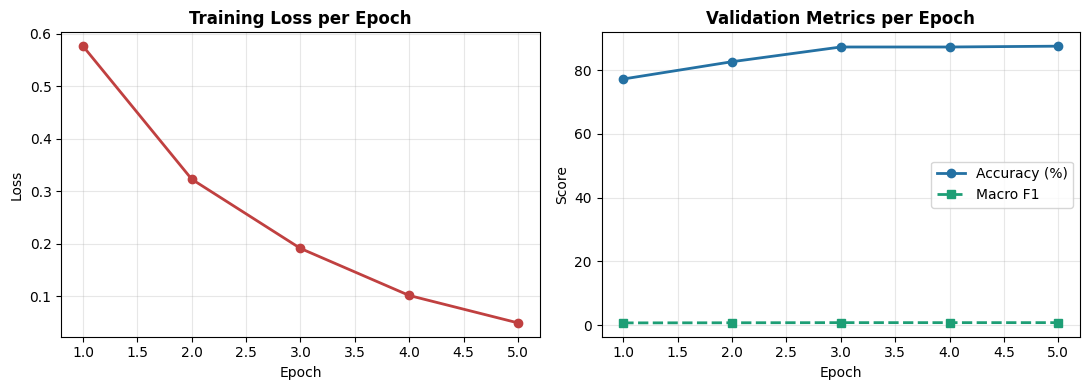

Plot tersimpan: training_history_pelabel.png


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 REVISI — Fine-tune IndoBERT + Class Weight
# Copy seluruh isi cell ini ke Cell 3 notebook Anda
# ═══════════════════════════════════════════════════════════════

from sklearn.utils.class_weight import compute_class_weight

# ── Class weight dari distribusi aktual ──────────────────────────────────────
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=df_train_lbl['label_enc'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print('Class weights (untuk menangani imbalance):')
for lbl, w in zip(['keluhan','saran','pujian'], class_weights):
    print(f'  {lbl:10s}: {w:.4f}')

# ── Dataset class ─────────────────────────────────────────────────────────────
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

class CommentDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.texts  = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True) if labels is not None else None

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            str(self.texts[idx]),
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        item = {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
        }
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# ── DataLoader ────────────────────────────────────────────────────────────────
train_dl = DataLoader(
    CommentDataset(df_train_lbl['text'], df_train_lbl['label_enc']),
    batch_size=BATCH_SIZE, shuffle=True, pin_memory=True
)
val_dl = DataLoader(
    CommentDataset(df_val_lbl['text'], df_val_lbl['label_enc']),
    batch_size=BATCH_SIZE, shuffle=False, pin_memory=True
)

# ── Model ─────────────────────────────────────────────────────────────────────
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, ignore_mismatched_sizes=True
)
model.to(DEVICE)

# ── Loss function dengan class weight ────────────────────────────────────────
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

# ── Optimizer & Scheduler ─────────────────────────────────────────────────────
optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_dl) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * 0.1),
    num_training_steps=total_steps
)

print(f'\nTraining info:')
print(f'  Batch size  : {BATCH_SIZE}')
print(f'  Epochs      : {EPOCHS}')
print(f'  Total steps : {total_steps:,}')
print(f'  Warmup steps: {int(total_steps * 0.1):,}')
print(f'  Device      : {DEVICE}')

# ── Training loop ─────────────────────────────────────────────────────────────
best_acc = 0.0
history  = []

for epoch in range(EPOCHS):

    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    total_loss = 0

    for batch in tqdm(train_dl, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]'):
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels    = batch['labels'].to(DEVICE)

        optimizer.zero_grad()

        # Forward pass tanpa label → hitung loss manual dengan class weight
        out  = model(input_ids=input_ids, attention_mask=attn_mask)
        loss = loss_fn(out.logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_dl)

    # ── Validasi ─────────────────────────────────────────────────────────────
    model.eval()
    preds_all, labels_all = [], []

    with torch.no_grad():
        for batch in tqdm(val_dl, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]  '):
            out = model(
                input_ids=batch['input_ids'].to(DEVICE),
                attention_mask=batch['attention_mask'].to(DEVICE)
            )
            preds_all.extend(torch.argmax(out.logits, 1).cpu().numpy())
            labels_all.extend(batch['labels'].numpy())

    val_acc  = accuracy_score(labels_all, preds_all)
    val_f1   = __import__('sklearn.metrics', fromlist=['f1_score']).f1_score(
        labels_all, preds_all, average='macro'
    )
    history.append({'epoch': epoch+1, 'loss': avg_loss,
                    'val_acc': val_acc, 'val_f1': val_f1})

    print(f'\nEpoch {epoch+1}/{EPOCHS}:')
    print(f'  Loss     : {avg_loss:.4f}')
    print(f'  Val Acc  : {val_acc*100:.2f}%')
    print(f'  Val F1   : {val_f1:.4f}  (macro)')

    # ── Simpan model terbaik berdasarkan Macro F1 ─────────────────────────────
    if val_f1 > getattr(model, '_best_f1', 0):
        model._best_f1 = val_f1
        best_acc = val_acc
        os.makedirs(MODEL_LABELER, exist_ok=True)
        model.save_pretrained(MODEL_LABELER)
        tokenizer.save_pretrained(MODEL_LABELER)
        print(f'  ✅ Model terbaik disimpan '
              f'(Acc: {best_acc*100:.2f}% | F1: {val_f1:.4f})')

# ── Laporan akhir ─────────────────────────────────────────────────────────────
print(f'\n{"="*55}')
print(f'Training selesai!')
print(f'  Best Val Acc : {best_acc*100:.2f}%')
print(f'  Best Val F1  : {model._best_f1:.4f}')
print(f'  Model disimpan di: {MODEL_LABELER}')
print(f'{"="*55}')

print(f'\nClassification Report (epoch terakhir):')
print(classification_report(
    labels_all, preds_all,
    target_names=['keluhan', 'saran', 'pujian'],
    digits=4
))

# ── Plot training history ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

epochs_x = [h['epoch'] for h in history]
ax1.plot(epochs_x, [h['loss']    for h in history], 'o-', color='#C04040', linewidth=2)
ax1.set_title('Training Loss per Epoch', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_x, [h['val_acc']*100 for h in history],
         'o-', color='#2471A3', linewidth=2, label='Accuracy (%)')
ax2.plot(epochs_x, [h['val_f1']      for h in history],
         's--', color='#1D9E75', linewidth=2, label='Macro F1')
ax2.set_title('Validation Metrics per Epoch', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'training_history_pelabel.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Plot tersimpan: training_history_pelabel.png')

## Cell 4 — Prediksi Label pada 54.532 Data yang Belum Berlabel
> Estimasi waktu: **~10–20 menit** (batch_size=32, GPU RTX 4060)

In [4]:
print('Memuat model terbaik...')
model_labeler = BertForSequenceClassification.from_pretrained(MODEL_LABELER)
model_labeler.to(DEVICE)
model_labeler.eval()

print('Memuat data unlabeled...')
df_unlabeled = pd.read_csv(FILE_UNLABELED)
df_unlabeled = df_unlabeled[['text']].dropna().reset_index(drop=True)
print(f'Data yang akan dilabeli: {len(df_unlabeled):,}')

unlabeled_dl = DataLoader(
    CommentDataset(df_unlabeled['text']),
    batch_size=32, shuffle=False
)

all_preds, all_probs = [], []
with torch.no_grad():
    for batch in tqdm(unlabeled_dl, desc='Prediksi label otomatis'):
        out   = model_labeler(
            input_ids=batch['input_ids'].to(DEVICE),
            attention_mask=batch['attention_mask'].to(DEVICE)
        )
        probs = torch.softmax(out.logits, dim=1)
        all_preds.extend(torch.argmax(probs,1).cpu().numpy())
        all_probs.extend(probs.max(1).values.cpu().numpy())

df_unlabeled['label_enc']  = all_preds
df_unlabeled['label_pks']  = [INV_LABEL_MAP[p] for p in all_preds]
df_unlabeled['confidence'] = all_probs

print(f'\nDistribusi label otomatis:')
vc = df_unlabeled['label_pks'].value_counts()
for lbl, cnt in vc.items():
    pct = cnt/len(df_unlabeled)*100
    print(f'  {lbl:10s}: {cnt:6,} ({pct:5.1f}%)')
print(f'\nConfidence rata-rata: {np.mean(all_probs):.4f}')
print(f'Confidence median   : {np.median(all_probs):.4f}')

Memuat model terbaik...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Memuat data unlabeled...
Data yang akan dilabeli: 50,002


Prediksi label otomatis:   0%|          | 0/1563 [00:00<?, ?it/s]


Distribusi label otomatis:
  keluhan   : 35,670 ( 71.3%)
  saran     :  9,330 ( 18.7%)
  pujian    :  5,002 ( 10.0%)

Confidence rata-rata: 0.9596
Confidence median   : 0.9975


## Cell 5 — Validasi 1: Noise Label Analysis

In [5]:
# Identifikasi label dengan confidence rendah (potensi salah label)
noise_mask  = df_unlabeled['confidence'] < THRESHOLD
noise_count = noise_mask.sum()
noise_pct   = noise_count / len(df_unlabeled) * 100

print(f'Noise Label Analysis (confidence < {THRESHOLD})')
print(f'=' * 45)
print(f'Data noise (confidence < {THRESHOLD}) : {noise_count:,} ({noise_pct:.2f}%)')
print(f'Data clean (confidence ≥ {THRESHOLD}) : {(~noise_mask).sum():,} ({100-noise_pct:.2f}%)')

# Distribusi confidence per bin
bins = [0, 0.50, 0.60, 0.70, 0.80, 0.90, 1.0]
labels_bin = ['0.0–0.5','0.5–0.6','0.6–0.7','0.7–0.8','0.8–0.9','0.9–1.0']
hist, _ = np.histogram(all_probs, bins=bins)
print(f'\nDistribusi confidence score:')
for lbl, cnt in zip(labels_bin, hist):
    pct = cnt/len(df_unlabeled)*100
    bar = '█' * int(pct/1)
    print(f'  [{lbl}]: {cnt:6,} ({pct:5.1f}%) {bar}')

# 5 contoh label noise (confidence terendah)
print(f'\n5 contoh label dengan confidence terendah:')
df_noise_sample = df_unlabeled.nsmallest(5, 'confidence')[['text','label_pks','confidence']]
for _, row in df_noise_sample.iterrows():
    print(f'  [{row.label_pks}|{row.confidence:.2f}] {str(row.text)[:80]}...')

# Simpan ringkasan untuk skripsi
print(f'\n📝 Untuk skripsi:')
print(f'   "Analisis noise label menunjukkan {noise_pct:.1f}% data memiliki')
print(f'   confidence score di bawah {THRESHOLD}, mengindikasikan potensi')
print(f'   ambiguitas linguistik pada komentar tersebut."')

Noise Label Analysis (confidence < 0.7)
Data noise (confidence < 0.7) : 2,365 (4.73%)
Data clean (confidence ≥ 0.7) : 47,637 (95.27%)

Distribusi confidence score:
  [0.0–0.5]:    141 (  0.3%) 
  [0.5–0.6]:  1,096 (  2.2%) ██
  [0.6–0.7]:  1,128 (  2.3%) ██
  [0.7–0.8]:  1,444 (  2.9%) ██
  [0.8–0.9]:  2,193 (  4.4%) ████
  [0.9–1.0]: 44,000 ( 88.0%) ███████████████████████████████████████████████████████████████████████████████████████

5 contoh label dengan confidence terendah:
  [keluhan|0.36] cukup satu kata parah😔...
  [pujian|0.36] ah ksian, tp sy jg ksian, lauk nya keseringan ikan patin mna kdng kek kecil kali...
  [saran|0.37] Gak usah 5 hr, keknya seminggu sekali aja udh cukup deh tpi YANG BENER-BENER ENA...
  [pujian|0.37] di kami terima pesanan barang kitchen equipmentnya , instalasi gas & pemasangan ...
  [saran|0.37] min aku mau kerja di sanaaaa...

📝 Untuk skripsi:
   "Analisis noise label menunjukkan 4.7% data memiliki
   confidence score di bawah 0.7, mengindikasikan po

## Cell 6 — Validasi 2: Spot Check Manual (200 sampel acak)

In [8]:
# Ambil 200 sampel acak untuk diperiksa secara manual
SPOT_N   = 200
df_spot  = df_unlabeled.sample(n=SPOT_N, random_state=SEED)[['text','label_pks','confidence']]
df_spot  = df_spot.reset_index(drop=True)

# Tambahkan kolom kosong untuk label manual Anda
df_spot['label_manual'] = ''  # ISI INI SECARA MANUAL

df_spot.to_csv(SPOT_FILE, index=False, encoding='utf-8-sig')

print(f'✅ File spot check tersimpan: {SPOT_FILE}')
print(f'\n📋 INSTRUKSI SPOT CHECK:')
print(f'   1. Buka file: {SPOT_FILE}')
print(f'   2. Baca kolom "text" (komentar asli)')
print(f'   3. Lihat kolom "label_pks" (label otomatis dari IndoBERT)')
print(f'   4. Isi kolom "label_manual" dengan penilaian Anda:')
print(f'      → ketikan: keluhan / saran / pujian')
print(f'   5. Simpan file, lalu jalankan Cell 9 untuk hitung kesesuaian')
print(f'   6. Target kesesuaian: ≥ 80% (sangat baik jika ≥ 85%)')

print(f'\n5 contoh pertama dari spot check:')
print(df_spot[['text','label_pks','confidence']].head().to_string())

✅ File spot check tersimpan: C:\Users\Lenovo\Downloads\skrips_code\xgboost_method\data_labelling\spot_check_200.csv

📋 INSTRUKSI SPOT CHECK:
   1. Buka file: C:\Users\Lenovo\Downloads\skrips_code\xgboost_method\data_labelling\spot_check_200.csv
   2. Baca kolom "text" (komentar asli)
   3. Lihat kolom "label_pks" (label otomatis dari IndoBERT)
   4. Isi kolom "label_manual" dengan penilaian Anda:
      → ketikan: keluhan / saran / pujian
   5. Simpan file, lalu jalankan Cell 9 untuk hitung kesesuaian
   6. Target kesesuaian: ≥ 80% (sangat baik jika ≥ 85%)

5 contoh pertama dari spot check:
                                                                                                                                                                                                                                              text label_pks  confidence
0                                                                                                                                         

In [11]:
# ── Filter hanya data dengan confidence < 0.70 ───────────────────────────────
df_noise = df_unlabeled[df_unlabeled['confidence'] < 0.70].copy()

print(f'Total data noise (confidence < 0.70) : {len(df_noise):,}')
print(f'Distribusi label data noise:')
for lbl, cnt in df_noise['label_pks'].value_counts().items():
    pct = cnt/len(df_noise)*100
    print(f'  {lbl:10s}: {cnt:,} ({pct:.1f}%)')

# ── Ambil sampel dari data noise ─────────────────────────────────────────────
# Ambil semua jika total noise < 200, ambil 200 jika lebih
SPOT_N   = min(200, len(df_noise))
df_spot  = df_noise.sample(n=SPOT_N, random_state=SEED)[
    ['text', 'label_pks', 'confidence']
]

# Urutkan confidence terendah di atas (yang paling meragukan didahulukan)
df_spot  = df_spot.sort_values('confidence', ascending=True)
df_spot  = df_spot.reset_index(drop=True)

# Tambahkan kolom kosong untuk label manual Anda
df_spot['label_manual'] = ''  # ISI INI SECARA MANUAL
df_spot['notes']        = ''  # opsional — tulis alasan jika berbeda

df_spot.to_csv('spot_check_confidence0.7.csv', index=False, encoding='utf-8-sig')

print(f'\n✅ File spot check tersimpan: {SPOT_FILE}')
print(f'   Total sampel : {len(df_spot):,} dari {len(df_noise):,} data noise')
print(f'   Confidence   : {df_spot["confidence"].min():.4f} s/d {df_spot["confidence"].max():.4f}')
print(f'\n📋 INSTRUKSI SPOT CHECK:')
print(f'   1. Buka file: {SPOT_FILE}')
print(f'   2. Baca kolom "text" — komentar asli')
print(f'   3. Lihat kolom "label_pks" — label otomatis IndoBERT')
print(f'   4. Isi kolom "label_manual" dengan penilaian Anda:')
print(f'      → ketik: keluhan / saran / pujian')
print(f'   5. Simpan file, lalu jalankan Cell 9 untuk hitung kesesuaian')
print(f'   6. Target kesesuaian: ≥ 80%')

print(f'\n5 contoh dengan confidence terendah:')
print(df_spot[['text','label_pks','confidence']].head().to_string())

Total data noise (confidence < 0.70) : 2,365
Distribusi label data noise:
  keluhan   : 1,097 (46.4%)
  saran     : 883 (37.3%)
  pujian    : 385 (16.3%)

✅ File spot check tersimpan: C:\Users\Lenovo\Downloads\skrips_code\xgboost_method\data_labelling\spot_check_200.csv
   Total sampel : 200 dari 2,365 data noise
   Confidence   : 0.3604 s/d 0.6992

📋 INSTRUKSI SPOT CHECK:
   1. Buka file: C:\Users\Lenovo\Downloads\skrips_code\xgboost_method\data_labelling\spot_check_200.csv
   2. Baca kolom "text" — komentar asli
   3. Lihat kolom "label_pks" — label otomatis IndoBERT
   4. Isi kolom "label_manual" dengan penilaian Anda:
      → ketik: keluhan / saran / pujian
   5. Simpan file, lalu jalankan Cell 9 untuk hitung kesesuaian
   6. Target kesesuaian: ≥ 80%

5 contoh dengan confidence terendah:
                                                                                                           text label_pks  confidence
0  ah ksian, tp sy jg ksian, lauk nya keseringan ikan patin mna

## Cell 7 — Validasi 3: Distribusi Kelas (Otomatis vs Manual)

In [9]:
# ── Cell 7 FIX — Validasi 3: Distribusi Kelas ────────────────────────────────

SEP = '=' * 52
HDR = f"{'Label':12s} | {'Manual':>10s} | {'Otomatis':>12s} | Status"
DIV = '-' * 52

print('Perbandingan distribusi kelas: Manual vs Otomatis')
print(SEP)

auto_dist = df_unlabeled['label_pks'].value_counts(normalize=True) * 100
manu_dist = df_labeled['label_pks'].value_counts(normalize=True) * 100

print(HDR)
print(DIV)
for lbl in ['keluhan', 'saran', 'pujian']:
    m    = manu_dist.get(lbl, 0)
    a    = auto_dist.get(lbl, 0)
    diff = abs(a - m)
    status = 'Konsisten' if diff < 15 else 'Berbeda jauh'
    flag   = 'OK' if diff < 15 else 'CEK'
    print(f'{lbl:12s} | {m:>9.1f}% | {a:>11.1f}% | {flag} {status}')

print(DIV)
print()
print('Catatan untuk skripsi:')
print('  Distribusi kelas data otomatis relatif konsisten dengan')
print('  distribusi data manual, mengindikasikan bahwa model pelabel')
print('  tidak mengalami bias sistematis terhadap kelas tertentu.')

Perbandingan distribusi kelas: Manual vs Otomatis
Label        |     Manual |     Otomatis | Status
----------------------------------------------------
keluhan      |      70.1% |        71.3% | OK Konsisten
saran        |      19.3% |        18.7% | OK Konsisten
pujian       |      10.6% |        10.0% | OK Konsisten
----------------------------------------------------

Catatan untuk skripsi:
  Distribusi kelas data otomatis relatif konsisten dengan
  distribusi data manual, mengindikasikan bahwa model pelabel
  tidak mengalami bias sistematis terhadap kelas tertentu.


## Cell 8 — Gabungkan Semua Data → 80.163 Dataset Final

In [10]:
# ══════════════════════════════════════════════════════════════
# CELL 8 FIX v2 — Reload dari file asli + gabungkan lengkap
# ══════════════════════════════════════════════════════════════

import pandas as pd
import os

# ── Reload dari file asli dengan semua kolom ─────────────────────────────────
print('Reload file asli dengan kolom lengkap...')

df_labeled_full   = pd.read_csv(FILE_LABELED)    # 18.534 label manual (semua kolom)
df_unlabeled_full = pd.read_csv(FILE_UNLABELED)  # 54.532 belum berlabel (semua kolom)

print(f'df_labeled_full   kolom: {list(df_labeled_full.columns)}')
print(f'df_unlabeled_full kolom: {list(df_unlabeled_full.columns)}')

# ── Tambahkan kolom label ke df_unlabeled dari hasil prediksi Cell 4 ─────────
# Ambil kolom label dari df_unlabeled (hasil prediksi sudah ada di variabel ini)
label_result = df_unlabeled[['text','label_pks','label_enc','confidence']].copy()
label_result['text_norm'] = label_result['text'].str.strip().str.lower()

# Merge hasil prediksi ke df_unlabeled_full berdasarkan text
df_unlabeled_full['text_norm'] = df_unlabeled_full['text'].str.strip().str.lower()
df_unlabeled_full = df_unlabeled_full.merge(
    label_result[['text_norm','label_pks','label_enc','confidence']],
    on='text_norm', how='left'
)
df_unlabeled_full['source'] = 'auto'
df_unlabeled_full = df_unlabeled_full.drop(columns=['text_norm'], errors='ignore')

# ── Siapkan df_labeled_full ───────────────────────────────────────────────────
df_labeled_full['source']     = 'manual'
df_labeled_full['confidence'] = 1.0
df_labeled_full['label_enc']  = df_labeled_full['label_pks'].map(LABEL_MAP)
df_labeled_full['platform'] = 'Instagram'


# ── Kolom final ───────────────────────────────────────────────────────────────
COLS_FINAL = [
    'id', 'timestamp', 'ownerUsername', 'text',
    'likesCount', 'postUrl', 'commentUrl',
    'platform', 'source_file',
    'label_pks', 'label_enc', 'confidence', 'source'
]

def safe_select(df, cols):
    for col in cols:
        if col not in df.columns:
            df[col] = None
    return df[cols].copy()

df_labeled_out   = safe_select(df_labeled_full,   COLS_FINAL)
df_unlabeled_out = safe_select(df_unlabeled_full, COLS_FINAL)

# ── Gabungkan ─────────────────────────────────────────────────────────────────
df_final = pd.concat([df_labeled_out, df_unlabeled_out], ignore_index=True)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

# ── Simpan ────────────────────────────────────────────────────────────────────
df_final.to_csv(OUTPUT_FULL, index=False, encoding='utf-8-sig')

# ── Laporan ───────────────────────────────────────────────────────────────────
SEP = '=' * 55
print(f'\n{SEP}')
print('DATASET BERLABEL — RINGKASAN FINAL')
print(SEP)
print(f'  Manual   : {(df_final["source"]=="manual").sum():,}')
print(f'  Otomatis : {(df_final["source"]=="auto").sum():,}')
print(f'  TOTAL    : {len(df_final):,}')

print(f'\nDistribusi label:')
for lbl, cnt in df_final['label_pks'].value_counts().items():
    pct = cnt / len(df_final) * 100
    bar = chr(9608) * int(pct / 3)
    print(f'  {lbl:10s}: {cnt:6,} ({pct:.1f}%) {bar}')

print(f'\nValidasi kolom:')
for col in COLS_FINAL:
    null_n  = df_final[col].isna().sum()
    status  = 'OK' if null_n == 0 else f'ADA {null_n:,} kosong'
    print(f'  {col:15s}: {status}')

print(f'\nFile tersimpan : {OUTPUT_FULL}')
print(f'\nLanjutkan ke Persiapan_Data_Labeling.ipynb Cell 6!')

Reload file asli dengan kolom lengkap...
df_labeled_full   kolom: ['id', 'timestamp', 'likesCount', 'postUrl', 'commentUrl', 'source_file', 'ownerUsername', 'text', 'label_pks']
df_unlabeled_full kolom: ['id', 'timestamp', 'ownerUsername', 'text', 'likesCount', 'postUrl', 'commentUrl', 'platform', 'source_file']

DATASET BERLABEL — RINGKASAN FINAL
  Manual   : 13,552
  Otomatis : 51,410
  TOTAL    : 64,962

Distribusi label:
  keluhan   : 46,197 (71.1%) ███████████████████████
  saran     : 12,114 (18.6%) ██████
  pujian    :  6,651 (10.2%) ███

Validasi kolom:
  id             : OK
  timestamp      : OK
  ownerUsername  : OK
  text           : OK
  likesCount     : OK
  postUrl        : OK
  commentUrl     : OK
  platform       : OK
  source_file    : OK
  label_pks      : OK
  label_enc      : OK
  confidence     : OK
  source         : OK

File tersimpan : C:\Users\Lenovo\Downloads\skrips_code\xgboost_method\data_labelling\labelled_data_final.csv

Lanjutkan ke Persiapan_Data_Labelin

## Cell 9 — Hitung Kesesuaian Spot Check (Jalankan setelah mengisi label_manual)
> Jalankan cell ini SETELAH Anda mengisi kolom `label_manual` di file spot_check_200.csv

In [15]:
# Baca kembali file spot check yang sudah diisi
df_spot_filled = pd.read_csv(SPOT_FILE)

# Filter hanya baris yang sudah diisi
df_spot_filled = df_spot_filled[df_spot_filled['label_manual'].notna()]
df_spot_filled = df_spot_filled[df_spot_filled['label_manual'].str.strip() != '']

if len(df_spot_filled) == 0:
    print('⚠️ Belum ada label manual yang diisi.')
    print('   Silakan isi kolom label_manual di file spot_check_200.csv terlebih dahulu.')
else:
    # Hitung kesesuaian
    df_spot_filled['label_manual'] = df_spot_filled['label_manual'].str.strip().str.lower()
    df_spot_filled['label_pks']    = df_spot_filled['label_pks'].str.strip().str.lower()

    match = (df_spot_filled['label_pks'] == df_spot_filled['label_manual']).sum()
    total = len(df_spot_filled)
    pct   = match / total * 100

    print(f'Hasil Spot Check ({total} sampel):')
    print(f'  Kesesuaian  : {match}/{total} ({pct:.1f}%)')
    print(f'  Ketidaksesuaian: {total-match}/{total} ({100-pct:.1f}%)')

    status = '✅ VALID' if pct >= 80 else '⚠️ Perlu review'
    print(f'  Status      : {status}')

    # Detail kesesuaian per kelas
    print(f'\nKesesuaian per kelas:')
    for lbl in ['keluhan', 'saran', 'pujian']:
        sub = df_spot_filled[df_spot_filled['label_manual'] == lbl]
        if len(sub) > 0:
            m = (sub['label_pks'] == sub['label_manual']).mean() * 100
            print(f'  {lbl:10s}: {m:.1f}% ({len(sub)} sampel)')

kalimat = (
    f'Validasi spot check manual terhadap {total} sampel acak '
    f'menunjukkan tingkat kesesuaian sebesar {pct:.1f}% antara '
    f'label otomatis dan penilaian peneliti, mengkonfirmasi '
    f'bahwa kualitas label otomatis memadai untuk penelitian ini.'
)
print('Kalimat untuk skripsi Bab 2:')
print(f'  "{kalimat}"')

Hasil Spot Check (200 sampel):
  Kesesuaian  : 180/200 (90.0%)
  Ketidaksesuaian: 20/200 (10.0%)
  Status      : ✅ VALID

Kesesuaian per kelas:
  keluhan   : 95.4% (131 sampel)
  saran     : 79.6% (49 sampel)
  pujian    : 84.2% (19 sampel)
Kalimat untuk skripsi Bab 2:
  "Validasi spot check manual terhadap 200 sampel acak menunjukkan tingkat kesesuaian sebesar 90.0% antara label otomatis dan penilaian peneliti, mengkonfirmasi bahwa kualitas label otomatis memadai untuk penelitian ini."
